In [ ]:
# Cifar10 data loading and preprocessing
from matplotlib import table
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split

#Transformations for data augmentation and normalization
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(), # Randomly flips the images to introduce variability
    transforms.RandomCrop(32, padding=4), # Randomly crops the images to 32x32 with padding of 4 pixels
    transforms.ToTensor(), #Converts the images to PyTorch Tensors
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5)) # Normalizes the images with mean and std deviation of 0.5 for each channel
])

# Transformations for validation set
transformVal = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
    # No random transformations for validation set
    # This ensures that the validation set is used as a representative sample of the data
])

# Donwload and load the CIFAR-10 dataset
train_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train= True,
    download=True,
    transform=transform
)

# Donwload and load the CIFAR-10 dataset
val_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train= False,
    download=True,
    transform=transformVal
)

# Define batch size which can be adjusted based on how well the model trains and the available computational resources
batch_size = 128

# Create DataLoaders for training and validation datasets
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True, # Shuffling the training data to ensure that the model does not learn the order of the data and generalizes better
    num_workers=2  # Number of subprocesses to use for data loading. 0 means that the data will be loaded in the main process, which can be slower. Setting it to 2 allows for faster data loading by using two subprocesses.
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False, # No need to shuffle validation data as it is only used for evaluation
    num_workers=2 
)

print(f"Dataset: CIFAR-10")
print(f"Number of classes: 10")
print(f"Image size: 32x32 pixels")
print(f"Batch size: {batch_size}")
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Dataset: CIFAR-10
Number of classes: 10
Image size: 32x32 pixels
Batch size: 128
Training samples: 50000
Validation samples: 10000
Using device: cuda


In [ ]:
# Creating VAE Model
import torch 
import torch.nn as nn
import torch.nn.functional as F

class VAE(nn.Module):
    def __init__(self, latent_dim=128):
        super(VAE, self).__init__()

        #Encoder 
        # Takes in a 3x32x32 image and compresses it to a latent representation of size latent_dim
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1), # Output: 32x16x16
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1), # Output: 64x8x8
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1), # Output: 128x4x4
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1), # Output: 256x2x2
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1), # Output: 512x1x1
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Flatten(), # Output: 512*1*1 = 512
        )

        # Mapping the flattened vector to the mean and log variance of the latent distribution
        self.fc_mu = nn.Linear(512, latent_dim) # Mean of the latent distribution
        self.fc_logvar = nn.Linear(512, latent_dim) # Log variance of the latent distribution

        # linear layer to expand latent vector before decoding
        self.decoder_input = nn.Linear(latent_dim, 512)

        #Decoder
        # Maps the latent vector back to the original image space
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1), # Output: 256x2x2
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1), # Output: 128x4x4
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1), # Output: 64x8x8
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1), # Output: 32x16x16
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1), # Output: 3x32x32
            nn.BatchNorm2d(3),
            nn.Tanh(), # Output pixel values between -1 and 1
            # nn.Sigmoid() # Output pixel values between 0 and 1, but since we normalized the images to be between -1 and 1, we use tanh instead
        )
        """
            Ask Professor if its possible to use seperate data loaders for the GAN and VAR, 
            tanh is used more for GAN but sigmoid is more commonly used for VAE, but since we normalized the images to be between -1 and 1, we use tanh instead.
        """
    def encode(self, x):
        x = self.encoder(x)
        mu = self.fc_mu(x) # Get the mean of the latent distribution
        logvar = self.fc_logvar(x) # Get the log variance of the latent distribution
        return mu, logvar
    
    def reparameterize(self, mu, logvar):
        # using log variance to calculate the standard deviation
        std = torch.exp(0.5*logvar) # Standard deviation of the latent distribution
        eps = torch.randn_like(std) # Random noise sampled from a standard normal distribution
        return mu + eps*std # Reparameterization trick to sample from the latent distribution
    
    def decode(self, z):
        x = self.decoder_input(z)
        x = x.view(-1, 512, 1, 1) # Reshape to 512x1x1 to match the first ConvTranspose2d input
        x = self.decoder(x)
        return x
    
    def forward(self, x):
        mu, logvar = self.encode(x) # Encode the input image to get the mean and log variance of the latent distribution
        z = self.reparameterize(mu, logvar) # Sample from the latent distribution using the reparameterization trick
        reconstructed_x = self.decode(z) # Decode the sampled latent vector to get the reconstructed image
        return reconstructed_x, mu, logvar
    
# Instantiate the VAE model and move it to the appropriate device (GPU if available, otherwise CPU)
vae = VAE(latent_dim=128).to(device)
print(vae)

VAE(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): Flatten(start_dim=1, end_dim=-1)
  )
  (fc_mu): Linear(in_features=2048, out_features=128, bias=True)
  (fc_logvar): Linear(in_features=2048, out_features=128, bias=True)
  (decoder_input): Linear(in_features=128, out_features=2048, bias=True)
  (decoder): Sequential(
    (0): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(32, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): Tanh()
  )
)


In [ ]:
# Calculating the ELBO loss for the VAE
import torch.optim as optim
import torch.nn.functional as F

def elbo_loss(recon_x, x, mu, logvar, beta=1.0):
    # Reconstruction Loss (MSE)
    # Summing over all pixels and averaging over the batch
    recon_loss = F.mse_loss(recon_x, x, reduction='sum')

    # KL Divergence Loss
    # -0.5 * sum(1 + logvar - mu^2 - exp(logvar))
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    # beta is provided by the caller via KL annealing schedule
    total_loss = recon_loss + beta * kl_loss

    return total_loss, recon_loss, kl_loss

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
# model instance should already be created and moved earlier; ensure it's on correct device
vae = vae.to(device)

#Standard optimizer adam
optimizer = optim.Adam(vae.parameters(), lr=1e-3)

epochs  = 40

# KL annealing: beta linearly ramps from 0 to beta_max over the warmup period,
# letting the model learn good reconstructions before the KL term kicks in.
kl_warmup_epochs = 10
beta_max = 1.0

# Lists to store the average losses for each epoch
history_total_loss = []
history_recon_loss = []
history_kl_loss = []
history_val_loss = []
history_beta = []

import time
start_time = time.time()

print("Starting training...")

# Initialize best validation loss to infinity
best_val_loss = float('inf')

vae.train()
for epoch in range(epochs):
    # KL annealing: linearly increase beta from 0 to beta_max over the warmup period
    beta = min(beta_max, beta_max * (epoch / kl_warmup_epochs))
    history_beta.append(beta)

    train_loss = 0.0
    train_recon = 0.0
    train_kl = 0.0

    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device) # Move the input data to the same device as the model

        # Zero the gradients before backpropagation
        optimizer.zero_grad()

        # Complete the forward pass through the VAE model
        recon_batch, mu, logvar = vae(data)

        # Calculate the ELBO loss with current annealed beta
        loss, recon_loss, kl_loss = elbo_loss(recon_batch, data, mu, logvar, beta=beta)

        # Backpropagation and optimization step
        loss.backward()
        optimizer.step()

        # Accumulate the losses (divded by batch size to get the average loss per sample)
        train_loss += loss.item() / data.size(0)
        train_recon += recon_loss.item() / data.size(0)
        train_kl += kl_loss.item() / data.size(0)

    # Calculate the average losses for this current epoch
    avg_loss = train_loss/(len(train_loader.dataset))
    avg_recon = train_recon/(len(train_loader.dataset))
    avg_kl = train_kl/(len(train_loader.dataset))

    # Store the values for plotting later
    history_total_loss.append(avg_loss)
    history_recon_loss.append(avg_recon)
    history_kl_loss.append(avg_kl)

    vae.eval() # Set the model to evaluation mode for validation
    val_loss = 0.0

    #Disable gradient calculation for validation to save memory and computation
    with torch.no_grad():
        for data, _ in val_loader:
            data = data.to(device)
            recon_batch, mu, logvar = vae(data)
            loss, _, _ = elbo_loss(recon_batch, data, mu, logvar, beta=beta)
            val_loss += loss.item() / data.size(0)
    
    avg_val_loss = val_loss/(len(val_loader.dataset))
    history_val_loss.append(avg_val_loss)

    print(f"Epoch [{epoch+1}/{epochs}] - Beta: {beta:.3f}, Total Loss: {avg_loss:.4f}, Recon Loss: {avg_recon:.4f}, KL Loss: {avg_kl:.4f}, Val Loss: {avg_val_loss:.4f}")

    # save best model each epoch
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(vae.state_dict(), 'best_vae.pth') # Save the best model

vae.load_state_dict(torch.load('best_vae.pth')) # Load the best model after training is complete
end_time = time.time()
print(f"Training complete. Best model loaded.")
print(f"Total training time: {end_time - start_time:.2f} seconds")

total_params = sum(p.numel() for p in vae.parameters())
trainable_params = sum(p.numel() for p in vae.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Using device: cuda
Starting training...
Epoch [1/40] - Total Loss: 3.0823, Recon Loss: 2.6691, KL Loss: 0.4131, Val Loss: 2.0839
Epoch [2/40] - Total Loss: 1.8319, Recon Loss: 1.3614, KL Loss: 0.4705, Val Loss: 1.7354
Epoch [3/40] - Total Loss: 1.6506, Recon Loss: 1.1762, KL Loss: 0.4744, Val Loss: 1.6209
Epoch [4/40] - Total Loss: 1.5798, Recon Loss: 1.0983, KL Loss: 0.4815, Val Loss: 1.5856
Epoch [5/40] - Total Loss: 1.5355, Recon Loss: 1.0440, KL Loss: 0.4916, Val Loss: 1.5404
Epoch [6/40] - Total Loss: 1.5122, Recon Loss: 1.0143, KL Loss: 0.4978, Val Loss: 1.5193
Epoch [7/40] - Total Loss: 1.4964, Recon Loss: 0.9946, KL Loss: 0.5017, Val Loss: 1.5009
Epoch [8/40] - Total Loss: 1.4839, Recon Loss: 0.9791, KL Loss: 0.5047, Val Loss: 1.4896
Epoch [9/40] - Total Loss: 1.4747, Recon Loss: 0.9674, KL Loss: 0.5073, Val Loss: 1.4910
Epoch [10/40] - Total Loss: 1.4682, Recon Loss: 0.9591, KL Loss: 0.5090, Val Loss: 1.4751
Epoch [11/40] - Total Loss: 1.4623, Recon Loss: 0.9523, KL Loss: 0.51

In [6]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


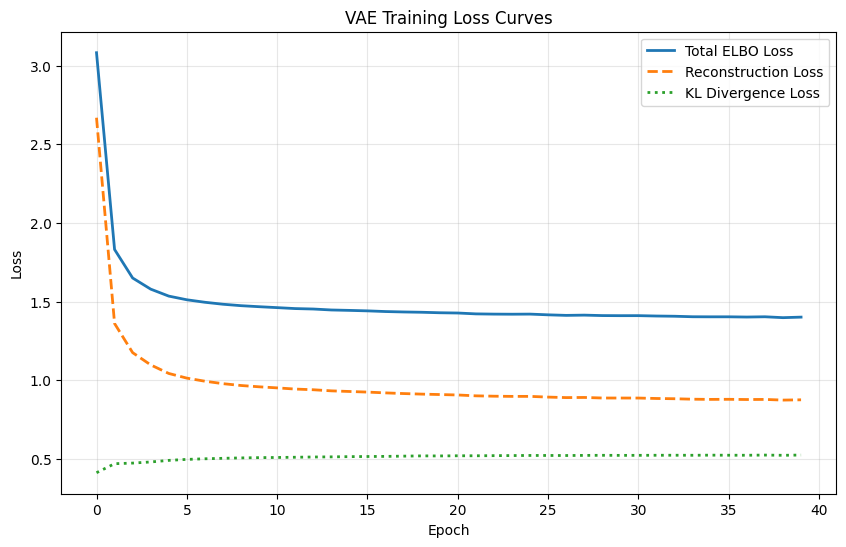

<Figure size 640x480 with 0 Axes>

In [ ]:
# Plotting the training and validation losses
import matplotlib.pyplot as plt

# Create a figre for the loss curves
plt.figure(figsize=(10, 6))

# Plot the three loss components
plt.plot(history_total_loss, label='Total ELBO Loss', linewidth=2)
plt.plot(history_recon_loss, label='Reconstruction Loss', linewidth=2, linestyle='--')
plt.plot(history_kl_loss, label='KL Divergence Loss', linewidth=2, linestyle=':')

plt.title('VAE Training Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig('vae_loss_curves.png', dpi=300, bbox_inches='tight')
plt.show()


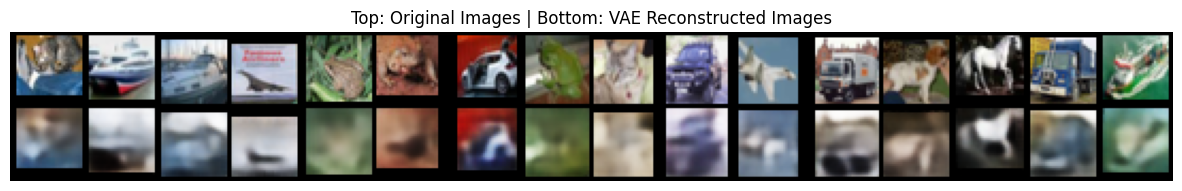

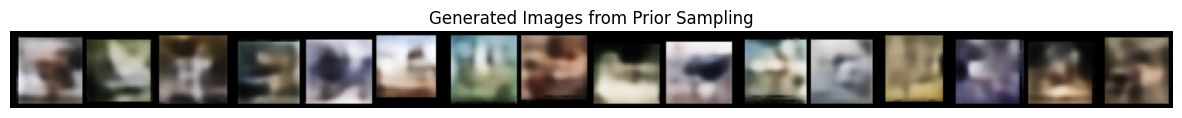

In [9]:
# Generating the 16 grid of images from the trained VAE model
from torch import tensor
import torchvision.utils as vutils

# Helper function to un-normalize the images for visualization
def unnormalize(img):
    return (img + 1) / 2.0 # Un-normalize the images from the range [-1, 1] back to [0, 1] for visualization

# Reconstructing images from the validation set to visualize the performance of the VAE
vae.eval() # Set the model to evaluation mode
# Grab a single batch of validation images
dataiter = iter(val_loader)
images, _ = next(dataiter)
images = images[:16].to(device) # Take the first 16 images from the batch and move them to the same device as the model

with torch.no_grad(): # Disable gradient calculation for inference
    recon_images, _, _ = vae(images) # Get the reconstructed images from the VAE

# Stack original and reconstructed images together for visualization
comparison = torch.cat([images, recon_images], dim=0)
# Create a grid of images and display it
comparison_grid = vutils.make_grid(unnormalize(comparison), nrow=16, padding=2)

plt.figure(figsize=(15, 4))
plt.imshow(comparison_grid.cpu().permute(1, 2, 0)) # Move the grid to CPU and permute dimensions for plotting
plt.title("Top: Original Images | Bottom: VAE Reconstructed Images")
plt.axis('off')
plt.savefig('vae_reconstructions.png', dpi=300, bbox_inches='tight')
plt.show()

# Prior sampling
# Sample random noise z ~ N(0, I) from the latent space and decode it to generate new images
z = torch.randn(16, 128).to(device) # Sample 16 random latent vectors from a standard normal distribution

with torch.no_grad():
    generated_images = vae.decode(z) # Decode the random latent vectors to generate new images

sample_grid = vutils.make_grid(unnormalize(generated_images), nrow=16, padding=2)
plt.figure(figsize=(15, 4))
plt.imshow(sample_grid.cpu().permute(1, 2, 0))
plt.title("Generated Images from Prior Sampling")
plt.axis('off')
plt.savefig('vae_generated_images.png', dpi=300, bbox_inches='tight')
plt.show()